<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/main/notebooks/viz_prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validación del módulo de visualización

Prueba de `src/viz/plot_grid.py` con el modelo `Grid` (Frente 2) para verificar el renderizado de los estados del autómata celular y la interacción entre fuego, tierra, agua y roca.

## 1. Convención de estados

| Código | Estado | Color | Descripción |
|:---:|:---|:---|:---|
| 0 | Sana | Verde (`#2ecc71`) | Vegetación viva, combustible disponible |
| 1 | Quemándose | Rojo (`#e74c3c`) | Frente de fuego activo |
| 2 | Quemada | Negro (`#111111`) | Biomasa consumida, material inerte |
| 3 | No-combustible | Gris (`#95a5a6`) | Barreras minerales (rocas, caminos) |
| 4 | Agua | Azul (`#3498db`) | Cuerpos de agua (ríos, lagos) |

Paleta discreta configurada con `ListedColormap` y `BoundaryNorm` para evitar interpolaciones de color.

In [1]:
import os

if os.path.exists('src'):
    pass
elif os.path.exists('../src'):
    %cd ..
else:
    if not os.path.exists('wildfire-cellular-automata'):
        !git clone https://github.com/anthony-yt/wildfire-cellular-automata.git
    %cd wildfire-cellular-automata

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from src.viz.plot_grid import dibujar_grid, animar_grid, generar_grid_dummy
from src.model.grid import Grid, SANA, NO_COMBUSTIBLE, AGUA

## 2. Visualización estática

Grilla de $50 \times 50$ con ignición, un río continuo de borde a borde (azul) y rocas dispersas (gris). Se ejecutan 5 pasos temporales para observar la interacción del fuego con el agua y la tierra.

In [3]:
grid = Grid(tamano=50, prob_ignicion_base=0.55, pasos_para_quemarse=2, semilla=273)

# Trazo de río continuo de borde a borde (Agua = 4, azul)
for r in range(grid.tamano):
    c = int(28 + 2.0 * np.sin(r / 4.0))
    if 0 <= c < grid.tamano:
        grid.agregar_rio(r, c)
    if 0 <= c + 1 < grid.tamano:
        grid.agregar_rio(r, c + 1)

# Insertar rocas dispersas adicionales (Gris = 3)
rng = np.random.default_rng(99)
for _ in range(40):
    r, c = rng.integers(0, grid.tamano, size=2)
    if grid.estado[r, c] == SANA:
        grid.agregar_obstaculo(r, c)

centro = grid.tamano // 2
grid.encender_celda(centro, centro - 7)

grid.contar_estados()

{'Sana': 2366, 'Quemandose': 1, 'Quemada': 0, 'No_combustible': 33, 'Agua': 100}

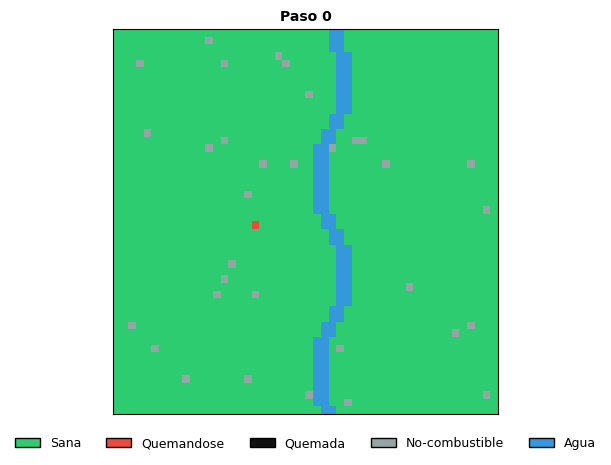

Paso 1: {'Sana': 2363, 'Quemandose': 4, 'Quemada': 0, 'No_combustible': 33, 'Agua': 100}


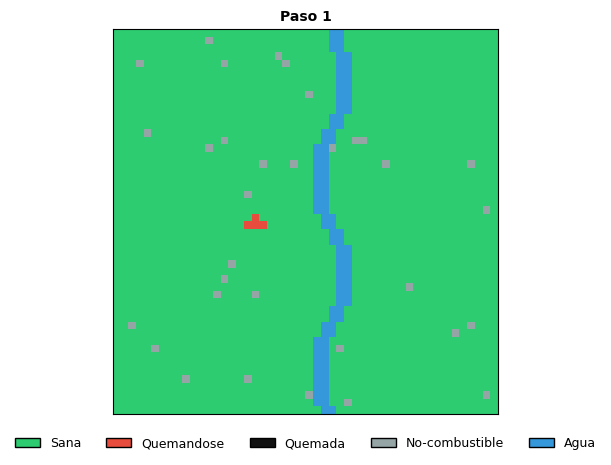

Paso 2: {'Sana': 2356, 'Quemandose': 10, 'Quemada': 1, 'No_combustible': 33, 'Agua': 100}


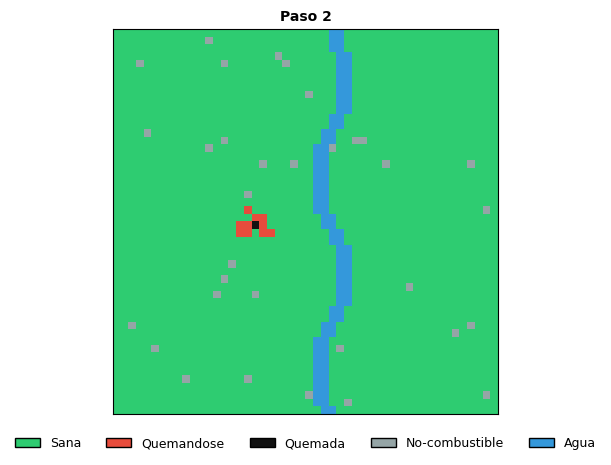

Paso 3: {'Sana': 2349, 'Quemandose': 14, 'Quemada': 4, 'No_combustible': 33, 'Agua': 100}


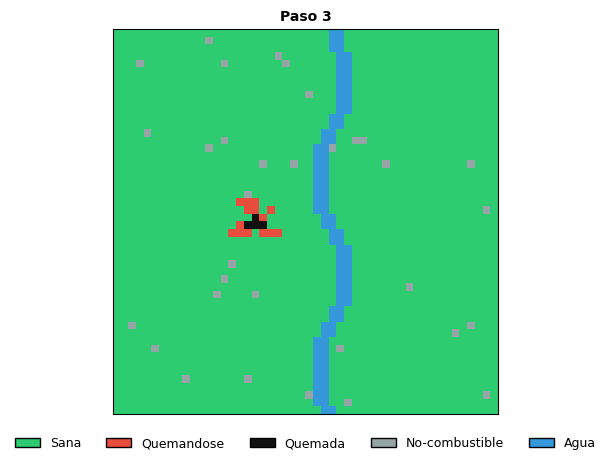

Paso 4: {'Sana': 2339, 'Quemandose': 17, 'Quemada': 11, 'No_combustible': 33, 'Agua': 100}


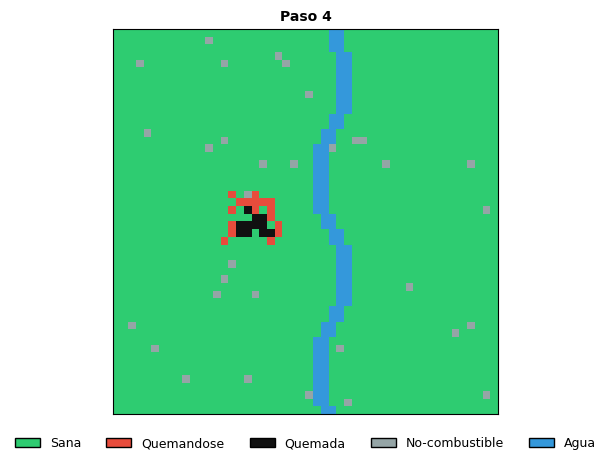

Paso 5: {'Sana': 2321, 'Quemandose': 28, 'Quemada': 18, 'No_combustible': 33, 'Agua': 100}


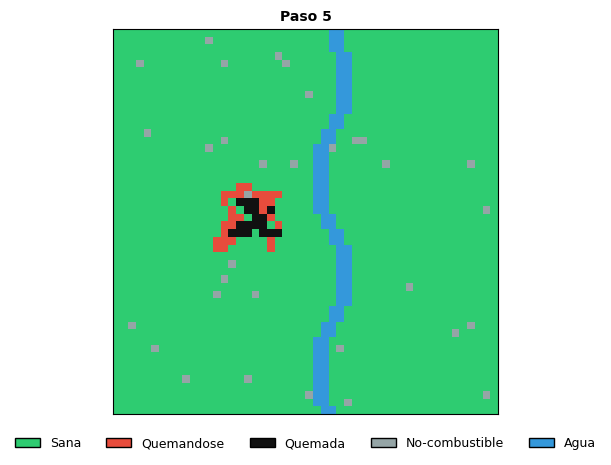

In [4]:
fig, ax, im = dibujar_grid(grid.estado, titulo="Paso 0")
plt.show()

for paso in range(1, 6):
    grid.paso_tiempo()
    print(f"Paso {paso}:", grid.contar_estados())
    fig, ax, im = dibujar_grid(grid.estado, titulo=f"Paso {paso}")
    plt.show()

## 3. Evolución temporal con obstáculos

Secuencia de 25 pasos generada con `generar_grid_dummy` ($30 \times 30$, río azul y rocas grises). El mosaico muestra cómo el fuego avanza sobre la vegetación y se detiene en el cauce del río.

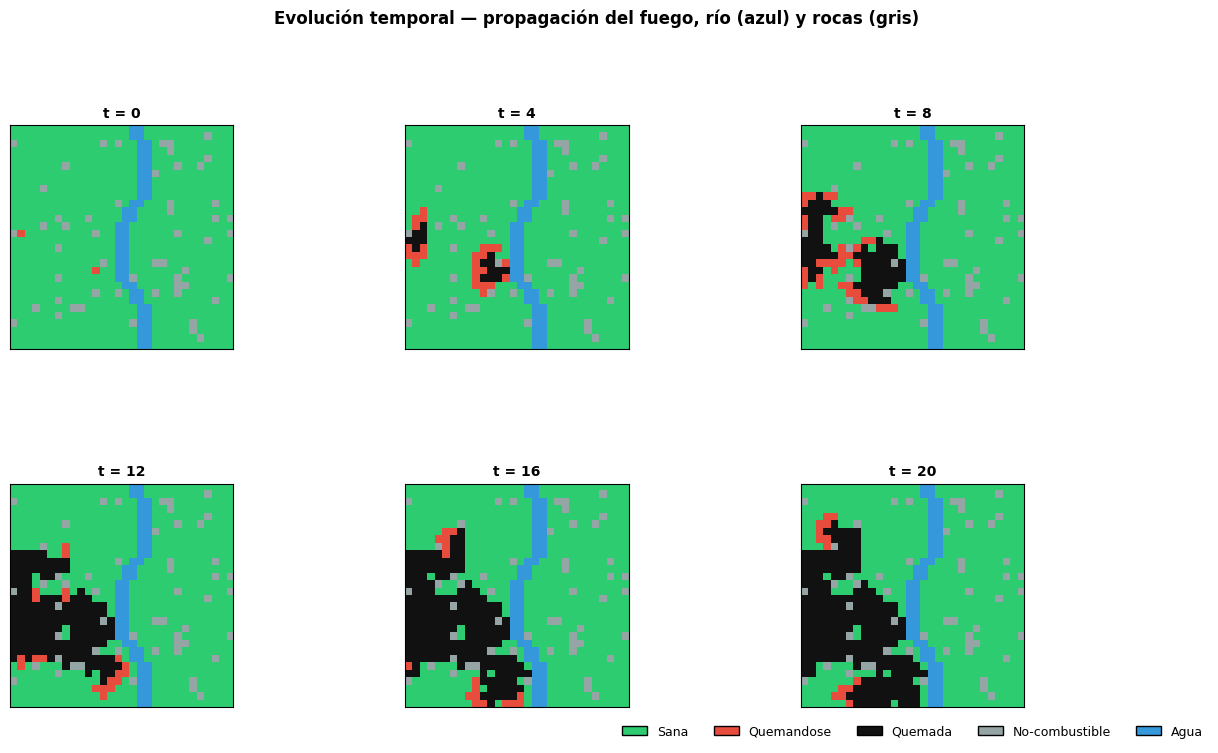

In [5]:
secuencia = generar_grid_dummy(
    n_pasos=25, tamano=30, n_puntos_ignicion=2,
    fraccion_no_combustible=0.06, duracion_quema=2, semilla=42
)

pasos = [0, 4, 8, 12, 16, 20]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, p in enumerate(pasos):
    ax = axes.flatten()[idx]
    dibujar_grid(secuencia[p], ax=ax, titulo=f"t = {p}", mostrar_leyenda=(idx == 5))
fig.suptitle("Evolución temporal — fuego, río (azul) y rocas (gris)", fontsize=12, weight="bold", y=1.0)
fig.tight_layout()
plt.show()

## 4. Animación interactiva

Animación de 30 pasos del modelo `Grid` con un río azul de borde a borde, renderizada con `animar_grid` y controles interactivos JavaScript/HTML.

In [6]:
sim = Grid(tamano=35, prob_ignicion_base=0.40, pasos_para_quemarse=2, semilla=123)

# Trazar un río azul continuo de borde a borde
for r in range(sim.tamano):
    c = int(20 + 2.0 * np.sin(r / 3.5))
    if 0 <= c < sim.tamano:
        sim.agregar_rio(r, c)
    if 0 <= c + 1 < sim.tamano:
        sim.agregar_rio(r, c + 1)

sim.encender_celda(17, 8)

secuencia_estados = [sim.estado.copy()]
for _ in range(30):
    sim.paso_tiempo()
    secuencia_estados.append(sim.estado.copy())

anim = animar_grid(
    secuencia_estados,
    intervalo=200,
    titulo_fn=lambda i: f"Frente 2 — Paso {i}"
)

plt.close(anim._fig)
HTML(anim.to_jshtml())

## 5. Conclusiones

1. **Fidelidad gráfica:** `dibujar_grid` y `animar_grid` representan nítidamente los estados discretos (diferenciando rocas grises y agua azul) sin artefactos de interpolación.
2. **Barreras inertes:** Las celdas de agua y rocas actúan como cortafuegos estables a lo largo de toda la simulación.
3. **Modularidad:** El módulo queda desacoplado del motor de cálculo y listo para consumir datos de viento, pendiente y coberturas reales.